# 02) GraphSAGE — node classification + K-sensitivity sweep (handover notebook)

This notebook starts from the `.npy` files produced by `01_preprocessing.ipynb` and runs the GraphSAGE pipeline:

1. Build a KNN graph over node features.
2. Wrap it in a PyG `Data` object with train/val/test masks.
3. Hyperparameter search via Optuna.
4. Multi-seed final training (mean +/- 95% CI).
5. **K-sensitivity sweep** — re-train at multiple `KNN_K` values to see how much the graph structure matters.
6. Figures.

## Why only GraphSAGE?

Earlier experiments tested GCN, GAT, GraphSAGE, GCNII, and GraphTransformer. GraphSAGE was the strongest performer; GAT was the weakest. The likely reasons:

- The KNN graph (built over BERT embeddings) is **highly homophilous** — neighbors mostly share the same sentiment label.
- BERT features are already class-discriminative, so attention has little signal to learn.
- GraphSAGE was designed for inductive settings (which is what we use).

For the planned RL graph-construction extension, sticking with the proven architecture is the right call. The RL agent will be more interesting than the choice of GNN backbone.

## What the K-sensitivity sweep tells you

Re-training GraphSAGE at `KNN_K = [5, 10, 15, 20, 30]` answers a critical question for the RL direction:

- **If accuracy is roughly flat across K**: the graph structure isn't the bottleneck. RL graph construction will struggle to find improvements. Reconsider the project framing.
- **If accuracy varies meaningfully**: there's a real signal for the RL agent to chase. Proceed.

This sweep is ~30 minutes on a GPU; do it before committing weeks to the RL infrastructure.

> **For the student:** start by running cells 1-7 to reproduce the baseline. Then run section 8 (the K-sweep) and use the results to decide whether to invest in the RL design.


## 1) Imports

In [1]:
import os
import json
import math
import random
import sys
import platform
from copy import deepcopy 
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # silently CPU-fallback unsupported MPS ops (PyG scatter etc.)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn
import torch.nn.functional as F

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from torch_geometric.data import Data
from torch_geometric.utils import to_undirected
from torch_geometric.nn import SAGEConv

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk", font="DejaVu Sans")

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")
print(f"PyTorch {torch.__version__} | MPS available={torch.backends.mps.is_available()} built={torch.backends.mps.is_built()}")


Using device: mps
PyTorch 2.10.0 | MPS available=True built=True


## 2) Configuration

Graph + GraphSAGE + training knobs. **Most experiments only require touching `KNN_K` and `KNN_K_SWEEP`.**

In [2]:
# === Paths ===
PROJECT_ROOT  = Path(".").resolve()
PREPROC_DIR   = Path("./preprocessed")        # produced by 01_preprocessing.ipynb
CACHE_DIR     = Path("./cache")               # cache for the KNN edge_index
RUN_DIR       = PROJECT_ROOT / "runs"
EXPERIMENT_TAG = "GETS_GNN_ONLY"
ARTIFACT_DIR  = RUN_DIR / EXPERIMENT_TAG
BEST_PARAMS_DIR = ARTIFACT_DIR / "best_params"
METRICS_DIR     = ARTIFACT_DIR / "metrics"
RESULTS_DIR     = ARTIFACT_DIR / "model_outputs"
PLOTS_DIR       = ARTIFACT_DIR / "plots"
for d in [BEST_PARAMS_DIR, METRICS_DIR, RESULTS_DIR, PLOTS_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print("Artifacts will be saved under:", ARTIFACT_DIR)

# === Reproducibility ===
SEED = 42
N_SEEDS = 10
SEEDS = [SEED + i for i in range(N_SEEDS)]

def set_global_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
set_global_seed(SEED)

# === Caching ===
USE_SAVED_BEST_PARAMS_IF_AVAILABLE = True
USE_CACHED_GRAPH = True

# === Graph induction ===
# - "transductive": one undirected KNN graph over all nodes
# - "inductive_directed": train forms KNN among itself; val/test attach via
#   directed edges train -> (val/test). Mirrors a deployment scenario.
GRAPH_MODE = "inductive_directed"
KNN_K       = 15                  # neighbors per node — bumped from 10 (K-sweep showed plateau at K>=15)
KNN_METRIC  = "cosine"            # cosine works well for normalized embeddings

# === Optuna ===
N_TRIALS = 50                     # 50 is a good default; lower for quick iteration
OPTIMIZE_METRIC = "accuracy"      # "accuracy" or "macro_f1"
OPTUNA_TIMEOUT_SEC = None

# === Training schedule ===
MAX_EPOCHS_TUNE  = 100            # Optuna trial budget per call
PATIENCE_TUNE    = 15
MAX_EPOCHS_FINAL = 300            # final multi-seed training budget
PATIENCE_FINAL   = 30

# === Which models to run ===
MODELS_TO_RUN = ["GraphSAGE"]     # only one model in this notebook

# === GraphSAGE Optuna search space ===
OPTUNA_SPACE_GRAPHSAGE = {
    "hidden_dim":   {"type": "categorical", "choices": [32, 64, 128, 256]},
    "dropout":      {"type": "float", "low": 0.2, "high": 0.5},
    "lr":           {"type": "float", "low": 1e-4, "high": 1e-2, "log": True},
    "weight_decay": {"type": "float", "low": 1e-6, "high": 1e-2, "log": True},
    "num_layers":   {"type": "int",   "low": 2,    "high": 6},
    "aggr":         {"type": "categorical", "choices": ["mean", "max"]},
}
OPTUNA_CONFIGS = {"GraphSAGE": {"space": OPTUNA_SPACE_GRAPHSAGE, "n_trials": N_TRIALS, "timeout_sec": OPTUNA_TIMEOUT_SEC}}

# === K-sensitivity sweep ===
# Set RUN_K_SWEEP=True before running Section 8 to enable.
RUN_K_SWEEP   = True              # re-sweep at K=15-tuned params for symmetry
KNN_K_SWEEP   = [5, 10, 15, 20, 30, 50, 100]
N_SEEDS_SWEEP = 5                 # 5 seeds gives tighter CIs that can separate adjacent Ks

# === Plotting ===
FIG_DPI = 200

# === Fixed labels ===
LABELS = ["negative", "neutral", "positive"]

print("Models to run:", MODELS_TO_RUN, "| KNN_K:", KNN_K, "| OPTIMIZE_METRIC:", OPTIMIZE_METRIC)


Artifacts will be saved under: /Users/fadi/Developer/Repositories/Sentiment-RL-Graph-Construction/runs/GETS_GNN_ONLY
Models to run: ['GraphSAGE'] | KNN_K: 15 | OPTIMIZE_METRIC: accuracy


## 3) Load preprocessed artifacts

Loads the `.npy` files from `01_preprocessing.ipynb`. If they're missing, run that notebook first.

In [3]:
required_files = [
    "X_train_bal.npy", "y_train_bal.npy",
    "X_sage_val.npy",  "y_sage_val.npy",
    "X_policy_val.npy", "y_policy_val.npy",
    "X_test.npy",      "y_test.npy",
    "metadata.json",
]
missing = [f for f in required_files if not (PREPROC_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing preprocessed files: {missing}\n"
        f"Run 01_preprocessing.ipynb first."
    )

X_train_bal  = np.load(PREPROC_DIR / "X_train_bal.npy")
y_train_bal  = np.load(PREPROC_DIR / "y_train_bal.npy")
X_sage_val   = np.load(PREPROC_DIR / "X_sage_val.npy")
y_sage_val   = np.load(PREPROC_DIR / "y_sage_val.npy")
X_policy_val = np.load(PREPROC_DIR / "X_policy_val.npy")
y_policy_val = np.load(PREPROC_DIR / "y_policy_val.npy")
X_test_bal   = np.load(PREPROC_DIR / "X_test.npy")
y_test_bal   = np.load(PREPROC_DIR / "y_test.npy")
metadata     = json.loads((PREPROC_DIR / "metadata.json").read_text())

print("Loaded preprocessed artifacts. Metadata:")
display(pd.DataFrame([{"key": k, "value": str(v)[:120]} for k, v in metadata.items() if k not in ("shapes", "label_counts")]))
print("Feature shapes:", X_train_bal.shape, X_sage_val.shape, X_policy_val.shape, X_test_bal.shape)


## 4) Build the PyG `Data` object (KNN graph)

Stack the three splits in the order `[train | val | test]` and build a KNN graph in feature space. Boolean masks select the relevant rows for loss/eval.

In `inductive_directed` mode (the default):
- Train nodes form an **undirected** KNN graph among themselves.
- Val nodes attach via **directed** edges train -> val (train messages reach val, but val never sends back).
- Test nodes attach the same way.

This means val/test nodes never message each other, mimicking a deployment scenario where test items are unseen at training time.

In [4]:
def edge_cache_path(n_total, n_train, n_sage_val, n_policy_val, n_test, knn_k=None) -> Path:
    k = KNN_K if knn_k is None else knn_k
    return CACHE_DIR / (
        f"edge_{GRAPH_MODE}_k{k}_{KNN_METRIC}_"
        f"n{n_total}_tr{n_train}_sv{n_sage_val}_pv{n_policy_val}_te{n_test}_"
        f"pca{metadata['pca_dim']}_{metadata['feature_scaling']}_"
        f"bal{metadata['balance_scope']}_{metadata['balance_method']}.pt"
    )

def build_knn_edges_inductive_directed(X_tr, X_sv, X_pv, X_te, knn_k: int) -> torch.Tensor:
    n_tr = X_tr.shape[0]

    # 1) Train-internal undirected graph.
    nn_tr = NearestNeighbors(n_neighbors=knn_k + 1, metric=KNN_METRIC, algorithm="brute").fit(X_tr)
    _, idx_tr = nn_tr.kneighbors(X_tr)
    src_tr = np.repeat(np.arange(n_tr), knn_k)
    dst_tr = idx_tr[:, 1:].reshape(-1)
    edge_tr = to_undirected(torch.tensor(np.vstack([src_tr, dst_tr]), dtype=torch.long))

    def directed_edges(X_target, offset):
        """Directed train -> target edges. offset = node index where target starts."""
        nn_ = NearestNeighbors(n_neighbors=knn_k, metric=KNN_METRIC, algorithm="brute").fit(X_tr)
        _, idx = nn_.kneighbors(X_target)
        return torch.tensor(np.vstack([
            idx.reshape(-1),
            np.repeat(np.arange(X_target.shape[0]), knn_k) + offset,
        ]), dtype=torch.long)

    edge_sv = directed_edges(X_sv, n_tr)
    edge_pv = directed_edges(X_pv, n_tr + X_sv.shape[0])
    edge_te = directed_edges(X_te, n_tr + X_sv.shape[0] + X_pv.shape[0])

    return torch.cat([edge_tr, edge_sv, edge_pv, edge_te], dim=1)

def build_knn_edges_transductive(X_all: np.ndarray, knn_k: int) -> torch.Tensor:
    nn_ = NearestNeighbors(n_neighbors=knn_k + 1, metric=KNN_METRIC, algorithm="brute").fit(X_all)
    _, idx = nn_.kneighbors(X_all)
    src = np.repeat(np.arange(X_all.shape[0]), knn_k)
    dst = idx[:, 1:].reshape(-1)
    return to_undirected(torch.tensor(np.vstack([src, dst]), dtype=torch.long))

def build_pyg_data(X_tr, y_tr, X_sv, y_sv, X_pv, y_pv, X_te, y_te, knn_k: int = None) -> 'Data':
    if knn_k is None:
        knn_k = KNN_K

    # Stack [train | sage_val | policy_val | test]
    X_all = np.vstack([X_tr, X_sv, X_pv, X_te]).astype(np.float32)
    y_all = np.concatenate([y_tr, y_sv, y_pv, y_te]).astype(int)
    n_tr, n_sv, n_pv, n_te = len(X_tr), len(X_sv), len(X_pv), len(X_te)
    n_total = n_tr + n_sv + n_pv + n_te

    train_mask      = torch.zeros(n_total, dtype=torch.bool)
    sage_val_mask   = torch.zeros(n_total, dtype=torch.bool)
    policy_val_mask = torch.zeros(n_total, dtype=torch.bool)
    test_mask       = torch.zeros(n_total, dtype=torch.bool)
    train_mask[:n_tr]                              = True
    sage_val_mask[n_tr:n_tr+n_sv]                 = True
    policy_val_mask[n_tr+n_sv:n_tr+n_sv+n_pv]     = True
    test_mask[n_tr+n_sv+n_pv:]                    = True

    edge_path = edge_cache_path(n_total, n_tr, n_sv, n_pv, n_te, knn_k=knn_k)
    if edge_path.exists() and USE_CACHED_GRAPH:
        print(f"[cache] edge_index: {edge_path.name}")
        edge_index = torch.load(edge_path, weights_only=False)
    else:
        print(f"[compute] edge_index ({GRAPH_MODE}, K={knn_k})")
        if GRAPH_MODE == "transductive":
            edge_index = build_knn_edges_transductive(X_all, knn_k)
        elif GRAPH_MODE == "inductive_directed":
            edge_index = build_knn_edges_inductive_directed(X_tr, X_sv, X_pv, X_te, knn_k)
        else:
            raise ValueError(f"Unknown GRAPH_MODE='{GRAPH_MODE}'")
        torch.save(edge_index, edge_path)

    return Data(
        x=torch.tensor(X_all, dtype=torch.float32),
        edge_index=edge_index,
        y=torch.tensor(y_all, dtype=torch.long),
        train_mask=train_mask,
        sage_val_mask=sage_val_mask,
        policy_val_mask=policy_val_mask,
        test_mask=test_mask,
    ).to(device)

data = build_pyg_data(
    X_train_bal, y_train_bal,
    X_sage_val,  y_sage_val,
    X_policy_val, y_policy_val,
    X_test_bal,  y_test_bal,
)
print(data)


## 5) Graph statistics

Quick characterization of the constructed graph. **Edge homophily** (fraction of edges where both endpoints share a label) is the key number — high homophily favors GraphSAGE; low homophily would favor GAT/GCNII.

In [5]:
def graph_stats(data: Data) -> dict:
    src, dst = data.edge_index.cpu().numpy()
    deg = np.bincount(src, minlength=data.num_nodes)
    y = data.y.cpu().numpy()

    # Edge homophily over train-internal edges (both endpoints have known labels).
    train_mask = data.train_mask.cpu().numpy()
    edge_in_train = train_mask[src] & train_mask[dst]
    if edge_in_train.sum() > 0:
        same_label = (y[src] == y[dst]) & edge_in_train
        homophily = float(same_label.sum() / edge_in_train.sum())
    else:
        homophily = float("nan")

    return {
        "num_nodes": int(data.num_nodes),
        "num_edges": int(data.edge_index.size(1)),
        "avg_degree": float(deg.mean()),
        "max_degree": int(deg.max()),
        "isolated_nodes": int((deg == 0).sum()),
        "edge_homophily_train": homophily,
    }

stats = graph_stats(data)
display(pd.DataFrame([stats]).T.rename(columns={0: "value"}))


,value
num_nodes,35253.000000
num_edges,687867.000000
avg_degree,19.512297
max_degree,226.000000
isolated_nodes,11166.000000
edge_homophily_train,0.510647


## 6) Training + evaluation utilities

`train_gnn` runs full-batch training with **eval-mode metrics**: after each optimizer step, we re-run the forward pass with `model.eval()` (dropout off) before measuring train/val accuracy. This avoids dropout noise contaminating the early-stopping signal.

In [6]:
def compute_metrics(y_true, y_pred) -> dict:
    """Accuracy + macro precision/recall/F1."""
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": float(acc), "macro_precision": float(prec),
            "macro_recall": float(rec), "macro_f1": float(f1)}

def suggest_from_space(trial: optuna.Trial, space: dict) -> dict:
    params = {}
    for name, spec in space.items():
        t = spec["type"]
        if t == "categorical":
            params[name] = trial.suggest_categorical(name, spec["choices"])
        elif t == "int":
            params[name] = trial.suggest_int(name, spec["low"], spec["high"])
        elif t == "float":
            params[name] = trial.suggest_float(name, spec["low"], spec["high"], log=spec.get("log", False))
        else:
            raise ValueError(f"Unknown param type '{t}' for '{name}'")
    return params


def train_gnn(model, model_name, data, lr, weight_decay, max_epochs, patience, verbose=False):
    """Full-batch GNN training with early stopping.

    Returns:
        model      : same instance, with the BEST validation weights restored
        history    : list of per-epoch dicts (used for training-curve plots)
        best_score : highest val OPTIMIZE_METRIC observed
    """
    if OPTIMIZE_METRIC not in {"accuracy", "macro_f1"}:
        raise ValueError(f"OPTIMIZE_METRIC must be 'accuracy' or 'macro_f1', got {OPTIMIZE_METRIC!r}")

    model = model.to(device)
    data = data.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    ce_loss = nn.CrossEntropyLoss()

    best_score, best_state, wait = -1e9, None, 0
    history = []

    epoch_iter = tqdm(range(1, max_epochs + 1), desc=f"{model_name} (gnn)", leave=False)

    for epoch in epoch_iter:
        # ---- Train step (one full-graph optimizer update) ----
        model.train()
        optimizer.zero_grad(set_to_none=True)
        logits_train = model(data.x, data.edge_index)
        # Loss only attends to LABELED training nodes; val/test contribute to
        # message passing but not to the loss.
        loss = ce_loss(logits_train[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        train_loss = float(loss.detach().item())

        # ---- Eval step: recompute logits with dropout off ----
        model.eval()
        with torch.no_grad():
            logits = model(data.x, data.edge_index)
            tr_pred = F.softmax(logits[data.train_mask], dim=1).cpu().numpy().argmax(1)
            tr_true = data.y[data.train_mask].cpu().numpy()
            m_tr = compute_metrics(tr_true, tr_pred)

            val_logits = logits[data.sage_val_mask]
            val_loss = float(ce_loss(val_logits, data.y[data.sage_val_mask]).detach().item())
            va_pred = F.softmax(val_logits, dim=1).cpu().numpy().argmax(1)
            va_true = data.y[data.sage_val_mask].cpu().numpy()
            m_va = compute_metrics(va_true, va_pred)
            val_metric = float(m_va[OPTIMIZE_METRIC])

        history.append({
            "epoch": epoch,
            "train_loss": train_loss, "val_loss": val_loss,
            "train_accuracy": m_tr["accuracy"], "val_accuracy": m_va["accuracy"],
            "train_macro_f1": m_tr["macro_f1"], "val_macro_f1": m_va["macro_f1"],
            "val_metric": val_metric,
        })

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f"[{model_name}] epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_{OPTIMIZE_METRIC}={val_metric:.4f}")

        # Early stopping with 1e-12 tolerance to avoid float-tie issues.
        if val_metric > best_score + 1e-12:
            best_score, best_state, wait = val_metric, deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                break

    # Restore best weights so the caller evaluates on the peak model, not
    # the (slightly overfit) final epoch.
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, float(best_score)


def eval_gnn(model, data, mask):
    """Forward whole graph in eval mode; return (metrics, preds, probs) for `mask`."""
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)[mask]
        probs = F.softmax(logits, dim=1).detach().cpu().numpy()
        pred = probs.argmax(axis=1)
        y_true = data.y[mask].detach().cpu().numpy()
        m = compute_metrics(y_true, pred)
    return m, pred, probs

def maybe_clear_device_cache():
    try:
        if device.type == "cuda":  torch.cuda.empty_cache()
        elif device.type == "mps": torch.mps.empty_cache()
    except Exception:
        pass


## 7) GraphSAGE model + tune-and-train pipeline

Stack of `SAGEConv` layers. Each layer aggregates messages from neighbors using the chosen aggregator (`mean` or `max`), combines with the node's own representation, and applies a linear transformation.

In [7]:
class GraphSAGENet(nn.Module):
    """Stack of SAGEConv layers with ReLU + dropout between them."""
    def __init__(self, in_dim, hidden_dim, num_layers, dropout, aggr, num_classes=3):
        super().__init__()
        assert num_layers >= 2, "GraphSAGE num_layers must be >= 2"
        self.dropout = float(dropout)
        self.aggr = aggr
        self.convs = nn.ModuleList()
        # First layer: in_dim -> hidden_dim.
        self.convs.append(SAGEConv(in_dim, hidden_dim, aggr=aggr))
        # Hidden layers: hidden_dim -> hidden_dim.
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim, aggr=aggr))
        # Final layer: hidden_dim -> num_classes (raw logits).
        self.convs.append(SAGEConv(hidden_dim, num_classes, aggr=aggr))

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)            # raw logits

def build_graphsage(params, in_dim):
    return GraphSAGENet(
        in_dim=in_dim,
        hidden_dim=int(params["hidden_dim"]),
        num_layers=int(params["num_layers"]),
        dropout=float(params["dropout"]),
        aggr=str(params["aggr"]),
        num_classes=len(LABELS),
    )

# ---- IO helpers ----
def best_params_path(model_name): return BEST_PARAMS_DIR / f"{model_name}_best_params.json"
def best_model_path(model_name, seed=None):
    return RESULTS_DIR / (f"{model_name}_seed{seed}_best_model.pt" if seed is not None
                          else f"{model_name}_best_model.pt")
def save_json(p, obj): open(p, "w", encoding="utf-8").write(json.dumps(obj, indent=2))
def load_json(p):       return json.load(open(p, "r", encoding="utf-8"))

def ci95(values) -> float:
    """95% confidence half-width (Student's t with N-1 dof)."""
    vals = np.asarray(values, dtype=float)
    vals = vals[~np.isnan(vals)]
    if len(vals) <= 1:
        return 0.0
    std = float(vals.std(ddof=1))
    try:
        from scipy.stats import t
        tcrit = float(t.ppf(0.975, df=len(vals) - 1))
    except Exception:
        tcrit = 1.96
    return tcrit * std / math.sqrt(len(vals))

def aggregate_metrics_seed_dict(seed_metrics: dict):
    if not seed_metrics:
        return {}, {}
    keys = sorted({k for m in seed_metrics.values() for k in m.keys()})
    mean_m, ci_m = {}, {}
    for k in keys:
        vals = [float(seed_metrics[s].get(k, np.nan)) for s in seed_metrics.keys()]
        mean_m[k] = float(np.nanmean(np.asarray(vals)))
        ci_m[k] = float(ci95(vals))
    return mean_m, ci_m

def mean_probs_seed_dict(seed_probs: dict):
    if not seed_probs:
        return None
    return np.mean(np.stack(list(seed_probs.values()), axis=0), axis=0)


# ---- Result containers ----
best_params_all   = {}
models_trained, histories                         = {}, {}
val_metrics_seeds, test_metrics_seeds             = {}, {}
val_probs_seeds, test_probs_seeds                 = {}, {}
val_preds_seeds, test_preds_seeds                 = {}, {}
val_metrics, test_metrics, val_metrics_ci, test_metrics_ci = {}, {}, {}, {}
val_probs, test_probs, val_preds, test_preds                = {}, {}, {}, {}


def tune_and_train_gnn_model(model_name: str, build_fn, data: Data):
    """Two-phase training:
       1. Optuna search (best_params cached to JSON)
       2. Multi-seed final training, aggregated to mean +/- 95% CI.
    """
    if model_name not in MODELS_TO_RUN:
        return
    cfg = OPTUNA_CONFIGS[model_name]
    space = cfg["space"]
    n_trials = int(cfg.get("n_trials", N_TRIALS))
    timeout  = cfg.get("timeout_sec", OPTUNA_TIMEOUT_SEC)
    in_dim = int(data.num_features)

    # --- Phase 1: Optuna ---
    bp_path = best_params_path(model_name)
    if USE_SAVED_BEST_PARAMS_IF_AVAILABLE and bp_path.exists():
        print(f"[cache] best params for {model_name}: {bp_path.name}")
        best_p = load_json(bp_path)
    else:
        print(f"[optuna] tuning {model_name} ...")

        def objective(trial):
            set_global_seed(SEED)               # comparable across trials
            params = suggest_from_space(trial, space)
            model = build_fn(params, in_dim)
            _, _, best_score = train_gnn(
                model, model_name, data,
                lr=float(params["lr"]),
                weight_decay=float(params["weight_decay"]),
                max_epochs=MAX_EPOCHS_TUNE, patience=PATIENCE_TUNE, verbose=False,
            )
            maybe_clear_device_cache()
            return float(best_score)

        sampler = optuna.samplers.TPESampler(seed=SEED)
        study = optuna.create_study(direction="maximize", study_name=f"{model_name}_tune", sampler=sampler)
        study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=True)
        best_p = study.best_params
        save_json(bp_path, best_p)

    best_params_all[model_name] = best_p

    # --- Phase 2: multi-seed final training ---
    for d in [histories, val_metrics_seeds, test_metrics_seeds,
              val_probs_seeds, test_probs_seeds, val_preds_seeds, test_preds_seeds]:
        d.setdefault(model_name, {})

    for seed in SEEDS:
        set_global_seed(int(seed))
        model = build_fn(dict(best_p), in_dim)
        model, hist, _ = train_gnn(
            model, model_name, data,
            lr=float(best_p["lr"]),
            weight_decay=float(best_p["weight_decay"]),
            max_epochs=MAX_EPOCHS_FINAL, patience=PATIENCE_FINAL, verbose=False,
        )
        m_va, p_va, prob_va = eval_gnn(model, data, data.sage_val_mask)
        m_te, p_te, prob_te = eval_gnn(model, data, data.test_mask)
        # Also evaluate on the train mask at the best-checkpoint weights so
        # the train-val gap is auditable from validation_metrics_seeds.csv.
        m_tr, _, _ = eval_gnn(model, data, data.train_mask)
        m_va = {**m_va, **{f"train_{k}": v for k, v in m_tr.items()}}

        histories[model_name][int(seed)]          = hist
        val_metrics_seeds[model_name][int(seed)]  = m_va
        test_metrics_seeds[model_name][int(seed)] = m_te
        val_probs_seeds[model_name][int(seed)]    = prob_va
        test_probs_seeds[model_name][int(seed)]   = prob_te
        val_preds_seeds[model_name][int(seed)]    = p_va
        test_preds_seeds[model_name][int(seed)]   = p_te

        try: torch.save(model.state_dict(), best_model_path(model_name, seed=int(seed)))
        except Exception: pass

        models_trained[model_name] = model
        maybe_clear_device_cache()

    # --- Aggregate ---
    mv, cv = aggregate_metrics_seed_dict(val_metrics_seeds[model_name])
    mt, ct = aggregate_metrics_seed_dict(test_metrics_seeds[model_name])
    val_metrics[model_name],  val_metrics_ci[model_name]  = mv, cv
    test_metrics[model_name], test_metrics_ci[model_name] = mt, ct
    val_probs[model_name]  = mean_probs_seed_dict(val_probs_seeds[model_name])
    test_probs[model_name] = mean_probs_seed_dict(test_probs_seeds[model_name])
    if val_probs[model_name]  is not None: val_preds[model_name]  = val_probs[model_name].argmax(axis=1)
    if test_probs[model_name] is not None: test_preds[model_name] = test_probs[model_name].argmax(axis=1)

    print(f"[done] {model_name}: "
          f"val_{OPTIMIZE_METRIC}={mv.get(OPTIMIZE_METRIC, np.nan):.4f} +/- {cv.get(OPTIMIZE_METRIC, 0.0):.4f} | "
          f"test_{OPTIMIZE_METRIC}={mt.get(OPTIMIZE_METRIC, np.nan):.4f} +/- {ct.get(OPTIMIZE_METRIC, 0.0):.4f}")


tune_and_train_gnn_model("GraphSAGE", build_graphsage, data)



### 7.1) Metrics summary

Two CSVs per split:
- `*_metrics_table.csv`: one row per model with mean + CI (paper-friendly)
- `*_metrics_seeds.csv`: one row per (model, seed) pair (for box plots)

In [8]:
def metrics_dict_to_df(d: dict) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(d, orient="index"); df.index.name = "model"
    return df.reset_index()

def seed_metrics_to_df(d: dict) -> pd.DataFrame:
    rows = []
    for model, seed_map in d.items():
        for seed, m in seed_map.items():
            row = {"model": model, "seed": int(seed)}; row.update(m); rows.append(row)
    return pd.DataFrame(rows)

if val_metrics and test_metrics:
    df_val_summary = (
        metrics_dict_to_df(val_metrics).set_index("model").add_suffix("_mean")
        .join(metrics_dict_to_df(val_metrics_ci).set_index("model").add_suffix("_ci"), how="left")
        .reset_index()
    )
    df_test_summary = (
        metrics_dict_to_df(test_metrics).set_index("model").add_suffix("_mean")
        .join(metrics_dict_to_df(test_metrics_ci).set_index("model").add_suffix("_ci"), how="left")
        .reset_index()
    )
    df_val_long  = seed_metrics_to_df(val_metrics_seeds)
    df_test_long = seed_metrics_to_df(test_metrics_seeds)

    df_val_summary.to_csv(METRICS_DIR / "validation_metrics_table.csv", index=False)
    df_test_summary.to_csv(METRICS_DIR / "test_metrics_table.csv", index=False)
    df_val_long.to_csv(METRICS_DIR / "validation_metrics_seeds.csv", index=False)
    df_test_long.to_csv(METRICS_DIR / "test_metrics_seeds.csv", index=False)

    print("=== Validation (mean +/- 95% CI) ===")
    display(df_val_summary)
    print("=== Test (mean +/- 95% CI) ===")
    display(df_test_summary)


=== Validation (mean +/- 95% CI) ===


,model,accuracy_mean,macro_f1_mean,macro_precision_mean,macro_recall_mean,train_accuracy_mean,train_macro_f1_mean,train_macro_precision_mean,train_macro_recall_mean,accuracy_ci,macro_f1_ci,macro_precision_ci,macro_recall_ci,train_accuracy_ci,train_macro_f1_ci,train_macro_precision_ci,train_macro_recall_ci
0,GraphSAGE,0.698066,0.70057,0.69767,0.707194,0.797223,0.795095,0.795588,0.797223,0.00218,0.002138,0.002154,0.001974,0.012103,0.012184,0.012226,0.012103


=== Test (mean +/- 95% CI) ===


,model,accuracy_mean,macro_f1_mean,macro_precision_mean,macro_recall_mean,accuracy_ci,macro_f1_ci,macro_precision_ci,macro_recall_ci
0,GraphSAGE,0.682331,0.685603,0.682631,0.692902,0.002232,0.002113,0.002096,0.002173


## 8) K-sensitivity sweep

Re-train GraphSAGE at multiple `KNN_K` values using the **already-tuned** hyperparameters. The reason we don't re-tune at each K: it would be 5x more compute, and the question we're asking ("does the graph structure matter?") doesn't require re-tuning.

### What we expect

| Outcome | Interpretation | Implication for the RL extension |
|---|---|---|
| Accuracy roughly flat across K | Graph structure is not the bottleneck | RL graph construction has limited headroom — reconsider the project framing |
| Accuracy varies meaningfully | Graph structure matters | RL agent has signal to chase — proceed |
| Sweet spot at moderate K (e.g., 10-15) | Standard concave curve | Confirms the default is reasonable |
| Best at very low or very high K | Default may be poorly tuned | Consider re-running the main pipeline with adjusted KNN_K |

> **For the student:** make sure `RUN_K_SWEEP = True` in the config cell before running.

In [9]:
def run_k_sweep(X_tr, y_tr, X_sv, y_sv, X_pv, y_pv, X_te, y_te, k_values, n_seeds_sweep: int = 3) -> pd.DataFrame:
    """Re-train GraphSAGE at each K with cached best params; return summary df."""
    bp_path = best_params_path("GraphSAGE")
    if not bp_path.exists():
        raise RuntimeError("No cached best params; run section 7 first.")
    best_p = load_json(bp_path)

    rows = []
    for k in k_values:
        print(f"\n[k-sweep] KNN_K={k}")
        data_k = build_pyg_data(X_tr, y_tr, X_sv, y_sv, X_pv, y_pv, X_te, y_te, knn_k=k)
        in_dim = int(data_k.num_features)

        seed_val, seed_test = {}, {}
        for s in [SEED + i for i in range(n_seeds_sweep)]:
            set_global_seed(int(s))
            model = build_graphsage(dict(best_p), in_dim)
            model, _, _ = train_gnn(
                model, f"SAGE@K={k}", data_k,
                lr=float(best_p["lr"]),
                weight_decay=float(best_p["weight_decay"]),
                max_epochs=MAX_EPOCHS_FINAL, patience=PATIENCE_FINAL, verbose=False,
            )
            m_va, _, _ = eval_gnn(model, data_k, data_k.sage_val_mask)
            m_te, _, _ = eval_gnn(model, data_k, data_k.test_mask)
            seed_val[s], seed_test[s] = m_va, m_te
            maybe_clear_device_cache()

        mv, cv = aggregate_metrics_seed_dict(seed_val)
        mt, ct = aggregate_metrics_seed_dict(seed_test)
        rows.append({
            "knn_k": k,
            "val_accuracy_mean":  mv["accuracy"],  "val_accuracy_ci":  cv["accuracy"],
            "val_macro_f1_mean":  mv["macro_f1"],  "val_macro_f1_ci":  cv["macro_f1"],
            "test_accuracy_mean": mt["accuracy"],  "test_accuracy_ci": ct["accuracy"],
            "test_macro_f1_mean": mt["macro_f1"],  "test_macro_f1_ci": ct["macro_f1"],
        })

    return pd.DataFrame(rows)

if RUN_K_SWEEP:
    df_sweep = run_k_sweep(X_train_bal, y_train_bal,
                           X_sage_val, y_sage_val,
                           X_policy_val, y_policy_val,
                           X_test_bal, y_test_bal,
                           KNN_K_SWEEP, N_SEEDS_SWEEP)
    df_sweep.to_csv(METRICS_DIR / "k_sweep.csv", index=False)
    print(f"\nK-sweep results saved to {METRICS_DIR / 'k_sweep.csv'}")
    display(df_sweep)
else:
    print("RUN_K_SWEEP is False. Set it to True in the config cell to run the sweep.")
    df_sweep = None


## 9) Figures

All figures are saved to `runs/<EXPERIMENT_TAG>/plots/`.

### 9.1) Class distribution (train split)

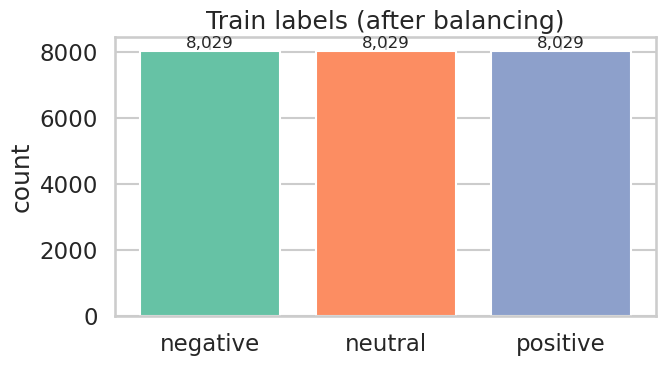

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = np.bincount(y_train_bal, minlength=len(LABELS))
ax.bar(LABELS, counts, color=sns.color_palette("Set2", n_colors=len(LABELS)))
for i, c in enumerate(counts):
    ax.text(i, c, f"{int(c):,}", ha="center", va="bottom", fontsize=12)
ax.set_title("Train labels (after balancing)"); ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "class_distribution_train.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


### 9.2) Training curves (validation accuracy + loss with 95% CI)

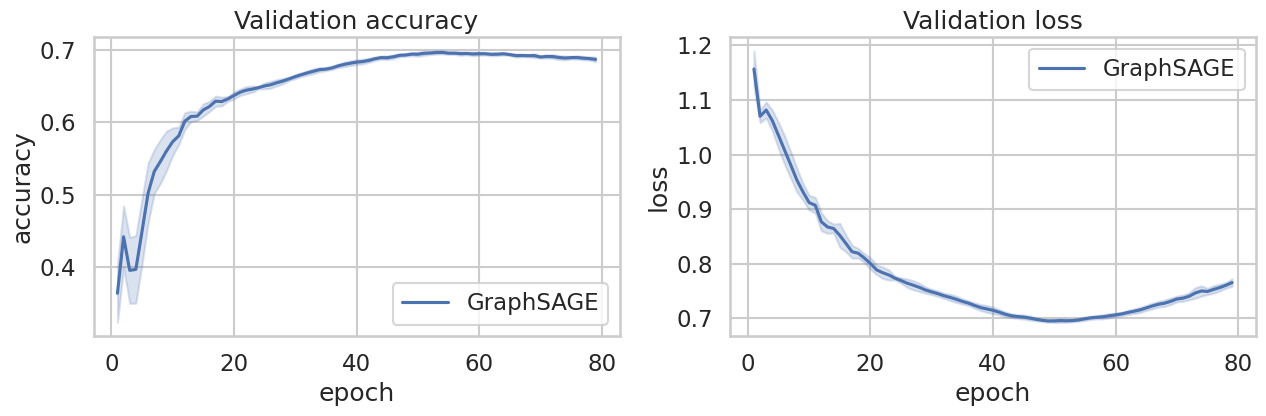

In [11]:
def stack_history(seed_hist: dict, key: str):
    """Pad-truncate per-seed histories to common length and stack to (n_seeds, L)."""
    if not seed_hist:
        return None
    series = [[ep[key] for ep in hist] for hist in seed_hist.values()]
    L = min(len(s) for s in series)
    return np.array([s[:L] for s in series])

if "GraphSAGE" in histories:
    arr_acc  = stack_history(histories["GraphSAGE"], "val_accuracy")
    arr_loss = stack_history(histories["GraphSAGE"], "val_loss")
    if arr_acc is not None and arr_loss is not None:
        epochs = np.arange(1, arr_acc.shape[1] + 1)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

        for ax, arr, title, ylabel in [
            (axes[0], arr_acc,  "Validation accuracy", "accuracy"),
            (axes[1], arr_loss, "Validation loss",     "loss"),
        ]:
            mean = arr.mean(0); std = arr.std(0, ddof=1)
            half = 1.96 * std / math.sqrt(arr.shape[0])
            ax.plot(epochs, mean, color="C0", label="GraphSAGE")
            ax.fill_between(epochs, mean - half, mean + half, color="C0", alpha=0.2)
            ax.set_title(title); ax.set_xlabel("epoch"); ax.set_ylabel(ylabel); ax.legend()

        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "training_curves.png", dpi=FIG_DPI, bbox_inches="tight")
        plt.show()


### 9.3) Confusion matrix (test, soft-voted across seeds)

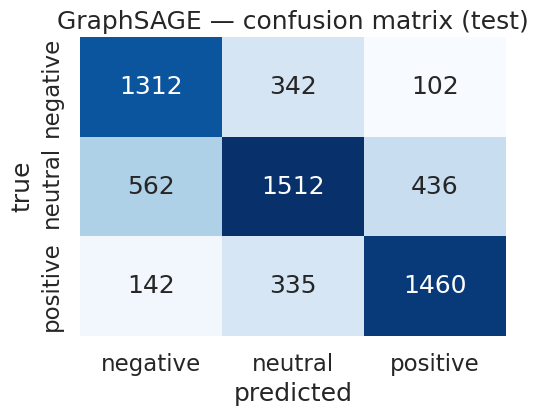

In [12]:
if "GraphSAGE" in test_preds:
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = test_preds["GraphSAGE"]
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABELS))))

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax)
    ax.set_title("GraphSAGE — confusion matrix (test)")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "confusion_matrix_graphsage.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()


### 9.4) ROC curve (micro-average, one-vs-rest)

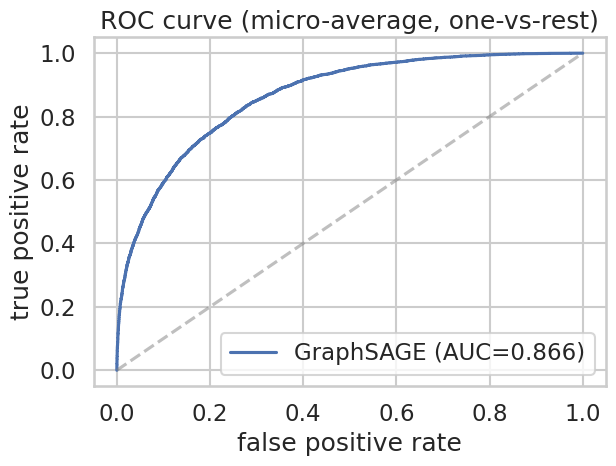

In [13]:
if "GraphSAGE" in test_probs:
    y_idx = data.y[data.test_mask].cpu().numpy()
    y_bin = label_binarize(y_idx, classes=list(range(len(LABELS))))
    probs = test_probs["GraphSAGE"]
    fpr, tpr, _ = roc_curve(y_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6.5, 5))
    plt.plot(fpr, tpr, color="C0", label=f"GraphSAGE (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], color="grey", linestyle="--", alpha=0.5)
    plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
    plt.title("ROC curve (micro-average, one-vs-rest)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "roc_graphsage.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()


### 9.5) K-sensitivity plot (the key figure for the RL go/no-go decision)

Lines = mean test metric across `N_SEEDS_SWEEP` seeds. Shaded band = 95% CI.

Look for: does the curve vary by more than a few CIs? If yes, the graph matters and RL has signal. If flat, reconsider.

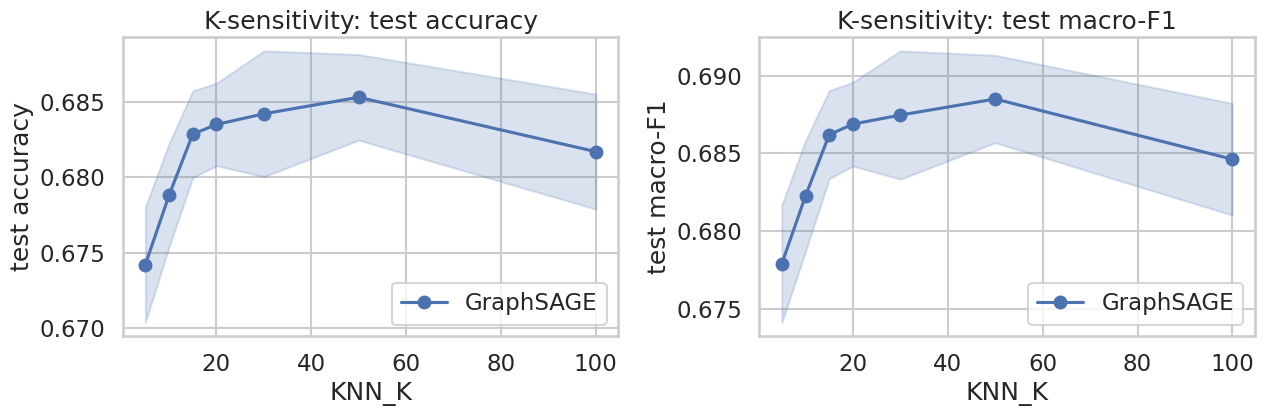

In [14]:
if df_sweep is not None and len(df_sweep) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for ax, (mean_col, ci_col, ylabel) in zip(axes, [
        ("test_accuracy_mean", "test_accuracy_ci", "test accuracy"),
        ("test_macro_f1_mean", "test_macro_f1_ci", "test macro-F1"),
    ]):
        m  = df_sweep[mean_col].values
        ci = df_sweep[ci_col].values
        ax.plot(df_sweep["knn_k"], m, marker="o", color="C0", label="GraphSAGE")
        ax.fill_between(df_sweep["knn_k"], m - ci, m + ci, color="C0", alpha=0.2)
        ax.set_xlabel("KNN_K"); ax.set_ylabel(ylabel)
        ax.set_title(f"K-sensitivity: {ylabel}")
        ax.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "k_sweep.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()


---

## 10) What to do next (notes for the student picking this up)

The baseline is finished. The numbers below are what your RL extension has to beat.

### Final baseline numbers (K=15, frozen)

| Metric | Value (mean ± 95% CI, 10 seeds) |
|---|---|
| **Test accuracy** | **0.6823 ± 0.0022** |
| Test macro-F1 | 0.6856 ± 0.0021 |
| Val accuracy | 0.6981 ± 0.0022 |
| Train accuracy | 0.797 ± 0.012 |
| ROC AUC (micro) | 0.866 |

Best hyperparameters (saved at `runs/GETS_GNN_ONLY/best_params/GraphSAGE_best_params.json`):

- `hidden_dim = 256`
- `num_layers = 4`
- `dropout = 0.234`
- `lr = 1.71e-3`
- `weight_decay = 6.0e-5`
- `aggr = "mean"`

### What the K-sweep tells us

The K-sweep across `K ∈ {5, 10, 15, 20, 30, 50, 100}` shows graph structure clearly matters:

- **K=5** (sparsest): test acc 0.6742
- **K=15** (default): test acc 0.6823
- **K=50** (peak): test acc 0.6853
- **K=100** (over-smoothed): test acc 0.6817

That ~1.1 percentage-point gap from K=5 to K=50 is your signal that RL has something to chase. If the curve had been flat, the project would have no clean story.

### What your RL extension has to beat

Two targets, in order of difficulty:

1. **Easy target — K=15 default baseline: 0.6823 test acc.**
   This is the published baseline. Your RL must clear this with non-overlapping CIs.

2. **Hard target — K=50 (the K-sweep peak): 0.6853 test acc.**
   This is the strongest fixed-K KNN. To claim RL produces *meaningfully better* graphs, you should clear this too. If RL only beats K=15 but loses to K=50, it means RL is no better than picking a smarter fixed K.

### Suggested first steps for you

1. **Read `RESEARCH_HANDOVER.md` end-to-end before writing any RL code.** It has the phased plan, design choices, and gotchas. Don't reinvent decisions.

2. **Reproduce these baseline numbers from a clean repo clone.** Restart kernel, Run All, confirm you get test accuracy within ±0.005 of 0.6823. If you can't reproduce, fix that before touching RL.

3. **Inspect per-class accuracy.** From the confusion matrix:
   - Negative recall: ~75%
   - **Neutral recall: ~60%** (this is the weakest class — most of your RL gains will likely come from improving this class)
   - Positive recall: ~75%

   The "neutral" class is the bottleneck. If your RL agent doesn't help neutral, it probably won't move the headline number.

4. **Build a candidate edge pool once, not per RL step.** Pre-compute a KNN-50 graph and let the policy choose which 10–15 of those 50 neighbors to keep per node. Don't recompute KNN inside the RL loop.

5. **Freeze the SAGE classifier.** The 10 model weights at `runs/GETS_GNN_ONLY/model_outputs/GraphSAGE_seed{42-51}_best_model.pt` are your starting point. Pick one (or use the soft-voted ensemble) and don't update its weights during RL training.

### Things NOT to do

- **Don't re-tune the SAGE model during RL training.** This makes the inner loop ~30× slower and conflates two sources of improvement (better graph vs. better classifier).
- **Don't reward the RL agent on val accuracy when SAGE early-stops on val.** That's double-dipping. See `RESEARCH_HANDOVER.md` section 9 for the fix (split val into sage_val and policy_val).
- **Don't change the data splits.** They're saved deterministically. Changing them invalidates the comparison.
- **Don't add more GNN architectures.** GraphSAGE was already the strongest of 5 we tested. Focus your time on the RL design instead.

### Files to know

| Path | What's in it |
|---|---|
| `./preprocessed/X_*.npy, y_*.npy` | Final feature/label arrays — load these, don't recompute |
| `./runs/GETS_GNN_ONLY/best_params/GraphSAGE_best_params.json` | Frozen hyperparameters |
| `./runs/GETS_GNN_ONLY/model_outputs/GraphSAGE_seed{42-51}_best_model.pt` | 10 trained SAGE models — pick one to freeze for RL |
| `./runs/GETS_GNN_ONLY/metrics/k_sweep.csv` | The full K-sweep — your "what RL has to beat" reference |
| `./cache/edge_*.pt` | Cached KNN graphs — reusable across runs |
| `./RESEARCH_HANDOVER.md` | Read this. All of it. |

Good luck.
